# Week 1 · Lab — Benchmark Suite, Experiment Harness and Baselines

**Goals**
- Tour the course's continuous benchmark suite (`utils.BENCHMARKS`): landscapes, known optima, modality,
  **separability**, and what `shifted_rotated` changes.
- Build the **experiment harness** used for the rest of the course: $R$ seeded runs under a `BudgetedObjective`,
  best-so-far traces on a common evaluation grid, median/IQR summaries, success rates, and the **expected running
  time** (ERT; Price 1997, Auger & Hansen 2005, as used in BBOB/COCO, Hansen et al. 2021) — validated against a
  closed form.
- Apply it to three baselines on all eight functions in $d = 10$: pure random search, a (1+1) hill climber with fixed
  Gaussian step, and random-restart local search.
- Derive the random-search scaling law $\mathbb{E}[\min f] \sim n^{-2/d}$ on the Sphere and verify it, including the
  constant.

**Prerequisites:** Notebooks 1–3 (evaluation budgets, local search, landscape structure).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import math
import time
from scipy.integrate import quad
from scipy.special import gamma
from utils import (BENCHMARKS, sphere, ellipsoid, rastrigin, shifted_rotated, random_rotation,
                   BudgetedObjective, BudgetExhausted, best_so_far_on_grid, PALETTE)

## 1. The benchmark suite

All functions are minimised on a box $[\ell, u]^d$ and have known optima, so every run can report its **error**
$f(x) - f^\ast$. We first check the recorded optima: $f(x^\ast) = f^\ast$ in $d = 2$ and $d = 10$, and no point in a large
uniform sample does better.

In [2]:
for name, b in BENCHMARKS.items():
    for d in (2, 10):
        check_close(b.f(b.x_opt(d)), b.f_opt, f"{name:10s} d={d:2d}: f(x_opt) = f_opt", atol=1e-6)
    sample = rng.uniform(b.lower, b.upper, (100_000, 2))
    check_true(b.f(sample).min() >= b.f_opt - 1e-9, f"{name:10s}: no sampled point beats f_opt  [{b.modality}]")

[PASS] sphere     d= 2: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] sphere     d=10: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] sphere    : no sampled point beats f_opt  [unimodal]
[PASS] ellipsoid  d= 2: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] ellipsoid  d=10: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] ellipsoid : no sampled point beats f_opt  [unimodal]
[PASS] rosenbrock d= 2: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] rosenbrock d=10: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] rosenbrock: no sampled point beats f_opt  [unimodal]
[PASS] rastrigin  d= 2: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] rastrigin  d=10: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] rastrigin : no sampled point beats f_opt  [multimodal]
[PASS] ackley     d= 2: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] ackley     d=10: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] ackley    : no sampled point beats f_opt  [multimodal]
[PASS] griewank   d= 2: f(x_opt) = f_opt: got 0.0, expec

[PASS] schwefel  : no sampled point beats f_opt  [deceptive]
[PASS] levy       d= 2: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] levy       d=10: f(x_opt) = f_opt: got 0.0, expected 0.0
[PASS] levy      : no sampled point beats f_opt  [multimodal]


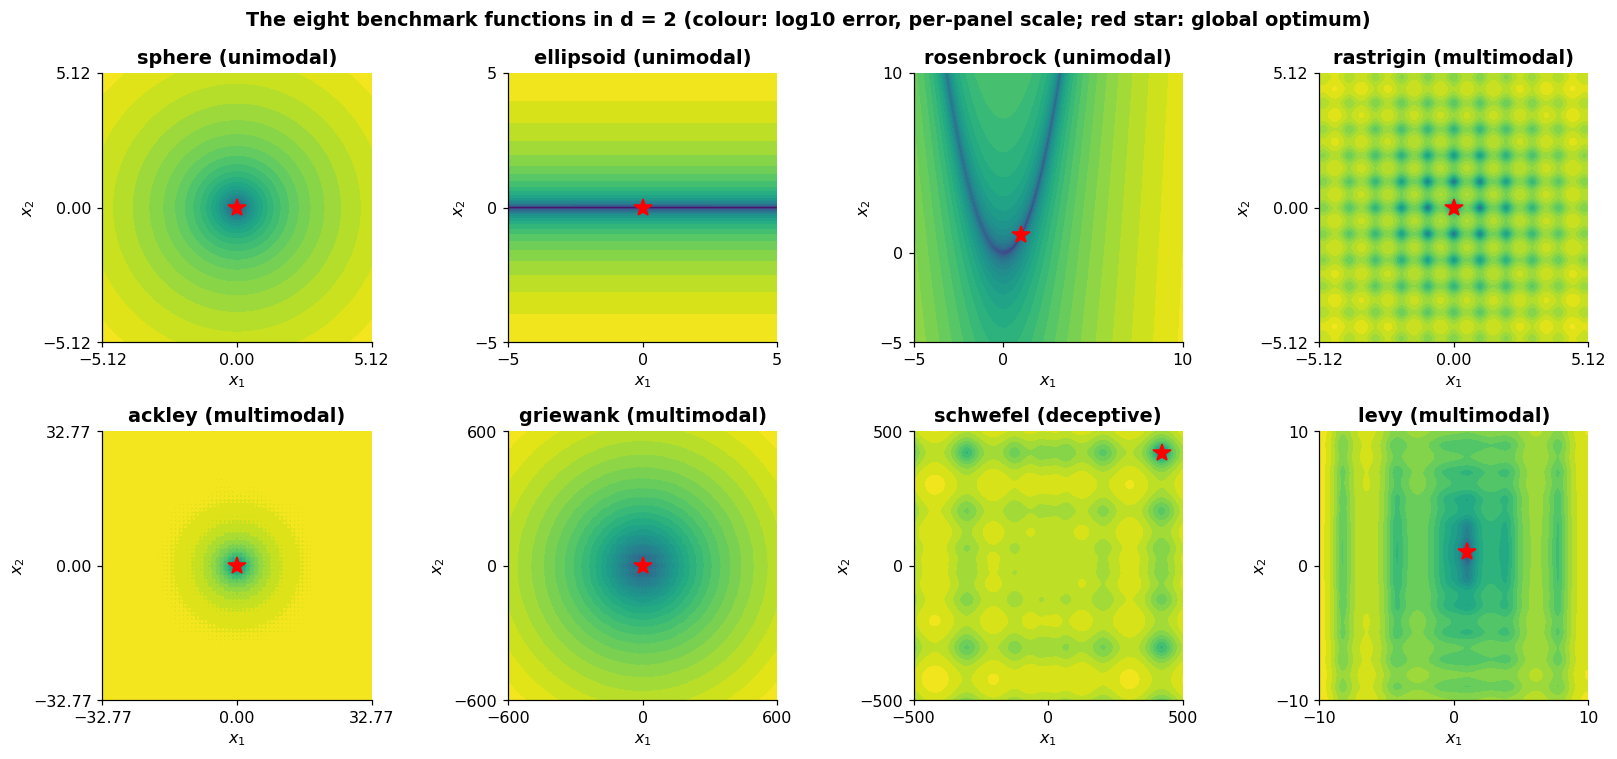

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, (name, b) in zip(axes.ravel(), BENCHMARKS.items()):
    g = np.linspace(b.lower, b.upper, 300)
    XX, YY = np.meshgrid(g, g)
    Z = b.f(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    ax.contourf(XX, YY, np.log10(Z - b.f_opt + 1e-3), levels=30, cmap="viridis")
    xo = b.x_opt(2)
    ax.plot(*xo, marker="*", color="red", ms=12)
    ax.set(title=f"{name} ({b.modality})", xticks=[b.lower, 0, b.upper], yticks=[b.lower, 0, b.upper])
    ax.set(xlabel="$x_1$", ylabel="$x_2$")
    ax.set_aspect("equal"); ax.grid(False)
fig.suptitle("The eight benchmark functions in d = 2 (colour: log10 error, per-panel scale; red star: global optimum)", fontweight="bold")
fig.tight_layout(); savefig("w1_benchmark_landscapes.png"); plt.show()

### Separability and rotation

$f$ is **additively separable** if $f(x) = \sum_i f_i(x_i)$. Then every mixed second difference vanishes:

$$\Delta_{ij} = f(\ldots a_i \ldots a_j \ldots) + f(\ldots b_i \ldots b_j \ldots) - f(\ldots a_i \ldots b_j \ldots) - f(\ldots b_i \ldots a_j \ldots) = 0,$$

and conversely (for $d = 2$, $\Delta \equiv 0$ implies $f(x_1,x_2) = g(x_1) + h(x_2)$). Separable functions can be
solved by $d$ independent one-dimensional searches — a structure (in the NFL sense) that coordinate-wise methods
exploit and that says nothing about real problems. `shifted_rotated(f, s, R)` evaluates $f(R(x - s))$: the shift
removes the "optimum at the centre" bias, the Haar-random rotation $R$ destroys separability (but not the
Sphere's, which is isotropic).

In [4]:
def max_mixed_difference(f, lo, hi, rng, d=2, m=2000):
    a, b = rng.uniform(lo, hi, (m, d)), rng.uniform(lo, hi, (m, d))
    ab, ba = a.copy(), b.copy(); ab[:, 1], ba[:, 1] = b[:, 1], a[:, 1]
    return np.max(np.abs(f(a) + f(b) - f(ab) - f(ba))) / (np.std(f(a)) + 1e-12)

sep = {name: max_mixed_difference(b.f, b.lower, b.upper, rng) for name, b in BENCHMARKS.items()}
for name, v in sep.items():
    print(f"{name:10s} max |mixed difference| / std(f) = {v:.2e}")
check_true({k for k, v in sep.items() if v < 1e-9} == {"sphere", "ellipsoid", "rastrigin", "schwefel", "levy"},
           "exactly sphere, ellipsoid, rastrigin, schwefel and levy are additively separable")
R2 = random_rotation(2, rng)
check_close(R2.T @ R2, np.eye(2), "random_rotation is orthogonal")
for name in ("sphere", "ellipsoid", "rastrigin"):
    b = BENCHMARKS[name]
    rot = shifted_rotated(lambda X, f=b.f: f(X), np.zeros(2), R2)
    print(f"rotated {name:10s}: max |mixed difference| / std = {max_mixed_difference(rot, b.lower, b.upper, rng):.2e}")

sphere     max |mixed difference| / std(f) = 1.28e-15
ellipsoid  max |mixed difference| / std(f) = 9.81e-16
rosenbrock max |mixed difference| / std(f) = 1.10e+00
rastrigin  max |mixed difference| / std(f) = 1.98e-15
ackley     max |mixed difference| / std(f) = 7.53e+00
griewank   max |mixed difference| / std(f) = 9.93e-02
schwefel   max |mixed difference| / std(f) = 1.64e-15
levy       max |mixed difference| / std(f) = 8.98e-16
[PASS] exactly sphere, ellipsoid, rastrigin, schwefel and levy are additively separable
[PASS] random_rotation is orthogonal: got [[1. 0.]
 [0. 1.]], expected [[1. 0.]
 [0. 1.]]
rotated sphere    : max |mixed difference| / std = 2.65e-15
rotated ellipsoid : max |mixed difference| / std = 8.62e+00
rotated rastrigin : max |mixed difference| / std = 5.27e+00


**Separability exploited.** One sweep of exact one-dimensional grid search per coordinate (a 1-D search on a grid of
2001 points, holding the other coordinates fixed) solves 10-D Rastrigin to grid precision; the same procedure on the
shifted-rotated version stalls far from the optimum.

In [5]:
def coordinate_sweep(f, lo, hi, d, rng, n_grid=2001):
    x = rng.uniform(lo, hi, d); g = np.linspace(lo, hi, n_grid)
    for i in range(d):
        X = np.repeat(x[None], n_grid, axis=0); X[:, i] = g
        x = X[int(np.argmin(f(X)))]
    return x, f(x)

d = 10
shift = rng.uniform(-2, 2, d); R10 = random_rotation(d, rng)
ras_rot = shifted_rotated(rastrigin, shift, R10)
check_close(ras_rot(shift), 0.0, "shifted-rotated Rastrigin: optimum moved to the shift, value 0")
_, f_sep = coordinate_sweep(rastrigin, -5.12, 5.12, d, rng)
_, f_rot = coordinate_sweep(ras_rot, -5.12, 5.12, d, rng)
print(f"coordinate sweep ({d * 2001} evaluations): separable Rastrigin error {f_sep:.2e}; rotated Rastrigin error {f_rot:.2f}")
check_true(f_sep < 1e-3 and f_rot > 1.0, "coordinate-wise search solves the separable version only")

[PASS] shifted-rotated Rastrigin: optimum moved to the shift, value 0: got 0.0, expected 0.0
coordinate sweep (20010 evaluations): separable Rastrigin error 0.00e+00; rotated Rastrigin error 99.85
[PASS] coordinate-wise search solves the separable version only


## 2. The experiment harness

Protocol (following COCO; Hansen et al. 2021):
1. An **optimiser** is a function `opt(F, rng, lo, hi, d, **params)` that queries the objective only through
   `F`, a `BudgetedObjective`, until it raises `BudgetExhausted`. The harness owns the budget, the seed and the counting,
   so optimisers cannot cheat.
2. Each of $R$ runs uses seed $s_r$. The best-so-far error $e_r(t) = \min_{i \le t} f(x_i) - f^\ast$ is recorded on a
   common logarithmic grid of evaluation counts.
3. **Summaries:** median and IQR of $e_r(t)$ over runs (robust to the heavy tails typical of stochastic search); the
   **success rate** $\hat p_s$ for a target error $\varepsilon$; and the **expected running time**

$$\mathrm{ERT}(\varepsilon) = \frac{\sum_{r} \mathrm{RT}_r(\varepsilon)}{\#\text{successful runs}},$$

where $\mathrm{RT}_r$ is the number of evaluations until run $r$ first reaches error $\le \varepsilon$, or its whole budget if
it never does. ERT estimates the expected cost of an algorithm *restarted independently until success*: with success
probability $p_s$ per run, $\mathrm{ERT} = \mathbb{E}[\mathrm{RT}_{\text{succ}}] + \frac{1-p_s}{p_s}\,\mathbb{E}[\mathrm{RT}_{\text{fail}}]$
(the same quantity is called ENES by Price 1997, SP2 by Auger & Hansen 2005, and ERT or aRT in BBOB/COCO).
Unlike "mean error at budget $B$", ERT compares algorithms that solve a problem at very different
speeds on a single, interpretable scale (evaluations).

In [6]:
# =====================================================================================================
# COURSE HARNESS  (Week 1 Lab)  — later weeks re-use / copy this cell verbatim
# =====================================================================================================
def run_optimizer(opt, f, budget, seed, lo, hi, d, f_opt=0.0, **params):
    """Run `opt(F, rng, lo, hi, d, **params)` once under a budget. Returns (evals, error) best-so-far trace."""
    F = BudgetedObjective(f, budget)
    try:
        opt(F, np.random.default_rng(seed), lo, hi, d, **params)
    except BudgetExhausted:
        pass
    ev, best = F.trace()
    return ev, best - f_opt

def run_experiment(opt, f, budget, seeds, lo, hi, d, f_opt=0.0, grid=None, **params):
    """R independent runs. Returns dict with the evaluation grid, errors on the grid (R x G) and raw traces."""
    if grid is None:
        grid = np.unique(np.round(np.logspace(0, np.log10(budget), 80)).astype(int))
    traces = [run_optimizer(opt, f, budget, s, lo, hi, d, f_opt, **params) for s in seeds]
    E = np.array([best_so_far_on_grid(ev, err, grid) for ev, err in traces])
    return {"grid": grid, "errors": E, "traces": traces, "budget": budget}

def summarise(res):
    """Median and interquartile range of the best-so-far error at each grid point."""
    q1, med, q3 = np.nanpercentile(res["errors"], [25, 50, 75], axis=0)
    return med, q1, q3

def running_times(res, target):
    """Per-run evaluations to reach error <= target (or evaluations used, if never) and success flags."""
    rts, succ = [], []
    for ev, err in res["traces"]:
        hit = np.flatnonzero(err <= target)
        succ.append(hit.size > 0)
        rts.append(ev[hit[0]] if hit.size else ev[-1])
    return np.array(rts, dtype=float), np.array(succ)

def success_rate(res, target):
    return running_times(res, target)[1].mean()

def ert(res, target):
    """Expected running time (ERT, as in BBOB/COCO): total evaluations / number of successes (inf if none)."""
    rts, succ = running_times(res, target)
    return rts.sum() / succ.sum() if succ.any() else np.inf
# =====================================================================================================

### Validating ERT against a closed form

Pure random search on the 2-D Sphere over $[-5.12, 5.12]^2$ with target $\varepsilon$: a sample succeeds iff it lands in
the disc of radius $\sqrt\varepsilon$, with probability $p = \pi\varepsilon / 10.24^2$ (the disc lies inside the box). The
running time of the restarted algorithm is geometric, so $\mathbb{E}[\mathrm{RT}] = 1/p$ exactly, and the per-run success
rate with budget $B$ is $1-(1-p)^B$.

In [7]:
def random_search(F, rng, lo, hi, d, batch=100):
    """Pure random search: i.i.d. uniform samples in the box (batched for speed; each row is one evaluation)."""
    while True:
        k = min(batch, F.remaining)
        if k <= 0:
            raise BudgetExhausted
        F(rng.uniform(lo, hi, (k, d)))

eps, B_val, R_val = 0.1, 1000, 400
p = math.pi * eps / 10.24**2
res_val = run_experiment(random_search, sphere, B_val, range(R_val), -5.12, 5.12, 2)
ert_hat, ps_hat = ert(res_val, eps), success_rate(res_val, eps)
rts, succ = running_times(res_val, eps)
# delta-method standard error of the ratio estimator mean(RT)/mean(succ), including the RT-success covariance:
# Var(ERT_hat) ~ Var(RT - ERT * succ) / (R * mean(succ)^2)
se_ert = np.std(rts - ert_hat * succ, ddof=1) / (np.sqrt(R_val) * ps_hat)
print(f"ERT = {ert_hat:.1f} +- {se_ert:.1f} evaluations   (closed form 1/p = {1 / p:.1f});  "
      f"success rate {ps_hat:.3f} (closed form {1 - (1 - p) ** B_val:.3f})")
check_close(ert_hat, 1 / p, "ERT of random search = 1/p", atol=4 * se_ert, rtol=0)
check_close(ps_hat, 1 - (1 - p) ** B_val, "per-run success rate = 1-(1-p)^B",
            atol=4 * np.sqrt(ps_hat * (1 - ps_hat) / R_val), rtol=0)

ERT = 338.2 +- 17.0 evaluations   (closed form 1/p = 333.8);  success rate 0.955 (closed form 0.950)
[PASS] ERT of random search = 1/p: got 338.217277, expected 333.772107
[PASS] per-run success rate = 1-(1-p)^B: got 0.955, expected 0.95024


## 3. Three baselines

Every later algorithm must beat these, at equal budget, to justify its complexity.

| Baseline | Representation | Variation | Acceptance | Memory | Stochasticity |
|---|---|---|---|---|---|
| Random search (RS) | $x \in [\ell,u]^d$ | none: fresh uniform sample | keep best | best-so-far | sampling |
| (1+1) hill climber (HC) | $x \in [\ell,u]^d$ | $y = \mathrm{clip}(x + \sigma z)$, $z \sim \mathcal{N}(0, I)$, **fixed** $\sigma$ | $f(y) \le f(x)$ | current point | step, start |
| Random-restart LS (RRLS) | same as HC | same as HC | same as HC; restart uniformly after $P$ non-improving steps | current + best | step, starts |

```text
(1+1)-HC(F, sigma):                 RRLS(F, sigma, P):
  x ~ U([l,u]^d); fx = F(x)           loop: run (1+1)-HC until P consecutive failures, then restart
  loop: y = clip(x + sigma z)
        if F(y) <= fx: x, fx = y, F(y)
```

Step size: $\sigma = 0.02\,(u - \ell)$ per coordinate for every function (no tuning); patience $P = 200$.
The (1+1) scheme with *adaptive* $\sigma$ (Rechenberg's 1/5 success rule, 1973) is an evolution strategy — the fixed-step
version is deliberately naive, and its stagnation below the step scale is the motivation for step-size control in later
weeks. Budget: $B = 400\,d = 4000$ evaluations, $R = 11$ seeds per (algorithm, function).

In [8]:
def hill_climber(F, rng, lo, hi, d, sigma_frac=0.02, patience=None):
    """(1+1) hill climber with fixed isotropic Gaussian step; with `patience`, restarts after that many failures."""
    sigma = sigma_frac * (hi - lo)
    while True:
        x = rng.uniform(lo, hi, d); fx = F(x); fails = 0
        while patience is None or fails < patience:
            y = np.clip(x + sigma * rng.standard_normal(d), lo, hi)
            fy = F(y)
            fails = 0 if fy < fx else fails + 1      # consecutive evaluations without strict improvement
            if fy <= fx:                             # accept ties: allows drift on plateaus
                x, fx = y, fy

def rr_local_search(F, rng, lo, hi, d, sigma_frac=0.02, patience=200):
    hill_climber(F, rng, lo, hi, d, sigma_frac, patience)

ALGOS = {"random search": (random_search, {}), "(1+1) hill climber": (hill_climber, {}),
         "random-restart LS": (rr_local_search, {})}
D, BUDGET, SEEDS = 10, 4000, range(11)
results = {}
t0 = time.perf_counter()
for fname, b in BENCHMARKS.items():
    for aname, (opt, params) in ALGOS.items():
        results[fname, aname] = run_experiment(opt, b.f, BUDGET, SEEDS, b.lower, b.upper, D, f_opt=b.f_opt, **params)
print(f"{len(results)} experiments x {len(SEEDS)} runs x {BUDGET} evaluations in {time.perf_counter() - t0:.1f} s")
check_true(all(len(r["traces"][i][0]) == BUDGET for r in results.values() for i in range(len(SEEDS))),
           "every run used exactly its budget (fair comparison)")

24 experiments x 11 runs x 4000 evaluations in 61.1 s
[PASS] every run used exactly its budget (fair comparison)


A unit test of the restart logic, independent of the harness: with a finite patience, fresh uniform restarts must show
up as evaluations far above the best value seen so far (a Gaussian step of size $\sigma$ from a near-optimal point
cannot produce them); without patience the climber never restarts.

In [9]:
class Recorder:
    """Minimal stand-in objective that records every value (to test restart logic independently of the harness)."""
    def __init__(self, f, budget):
        self.f, self.vals, self.budget = f, [], budget
    @property
    def remaining(self):
        return self.budget - len(self.vals)
    def __call__(self, x):
        if len(self.vals) >= self.budget:
            raise BudgetExhausted
        v = float(self.f(x)); self.vals.append(v); return v

rec = Recorder(sphere, 3000)
try:
    hill_climber(rec, np.random.default_rng(1), -5.12, 5.12, 2, sigma_frac=0.02, patience=50)
except BudgetExhausted:
    pass
v = np.array(rec.vals)
check_true(np.sum(v[1:] > 20 * np.minimum.accumulate(v)[:-1] + 5.0) >= 2, "patience restarts occur (fresh random starts)")
rec2 = Recorder(sphere, 3000)
try:
    hill_climber(rec2, np.random.default_rng(1), -5.12, 5.12, 2, sigma_frac=0.02, patience=None)
except BudgetExhausted:
    pass
v2 = np.array(rec2.vals)
check_true(np.sum(v2[1:] > 20 * np.minimum.accumulate(v2)[:-1] + 5.0) == 0 and len(v2) == 3000,
           "without patience: no restarts, whole budget used")

[PASS] patience restarts occur (fresh random starts)
[PASS] without patience: no restarts, whole budget used


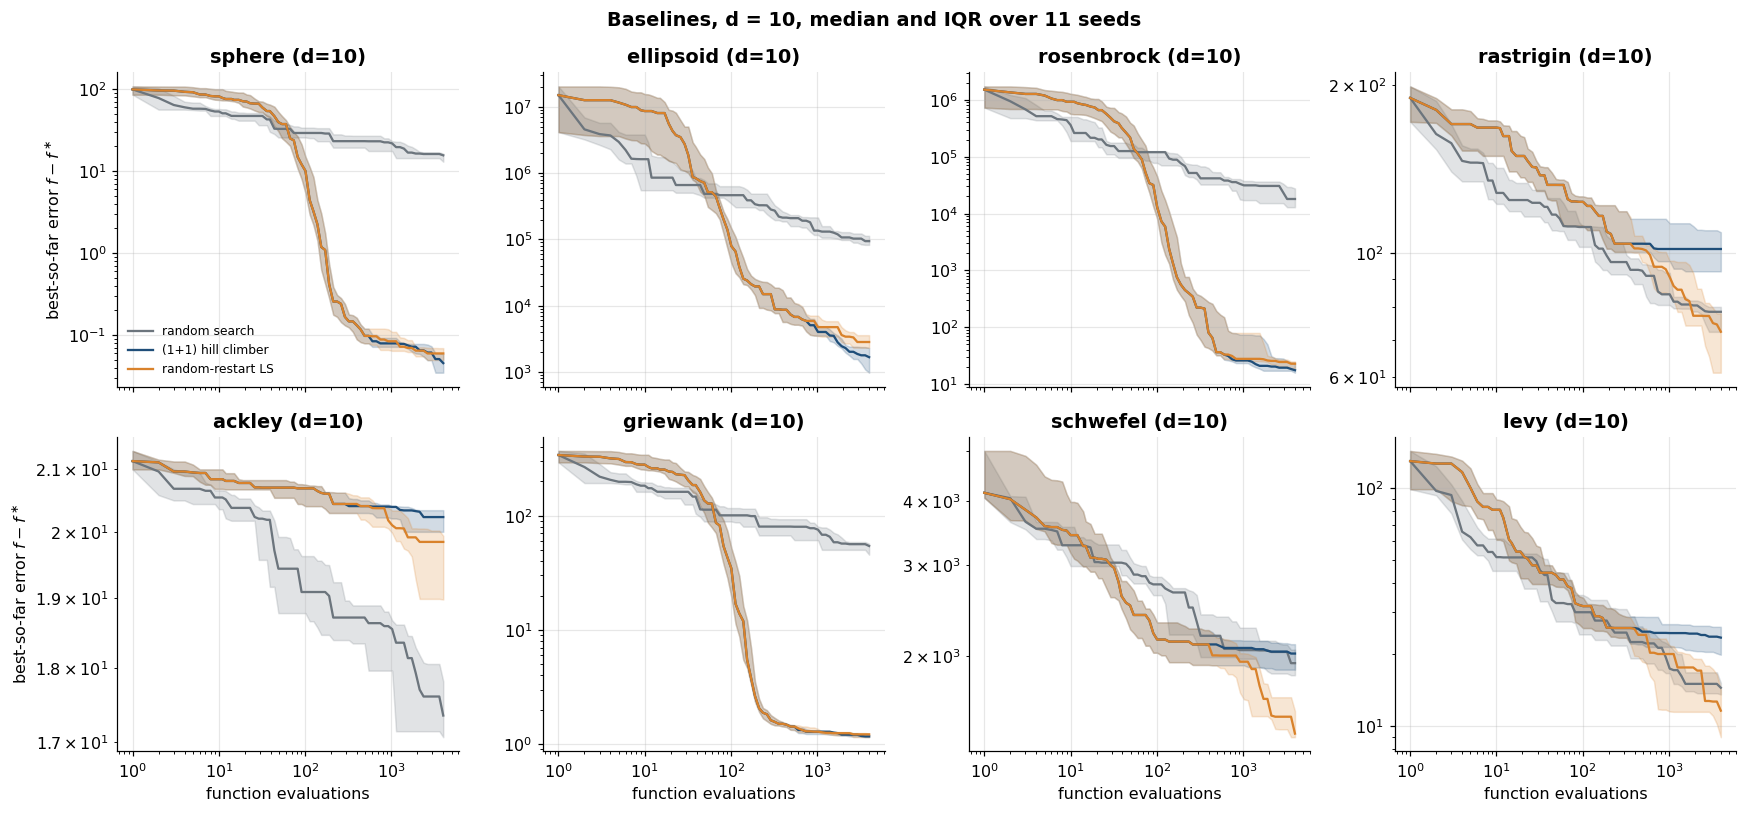

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharex=True)
cols = {"random search": PALETTE["grey"], "(1+1) hill climber": PALETTE["blue"], "random-restart LS": PALETTE["orange"]}
for ax, fname in zip(axes.ravel(), BENCHMARKS):
    for aname in ALGOS:
        r = results[fname, aname]
        med, q1, q3 = summarise(r)
        ax.plot(r["grid"], med, color=cols[aname], label=aname)
        ax.fill_between(r["grid"], q1, q3, color=cols[aname], alpha=0.2)
    ax.set(xscale="log", yscale="log", title=f"{fname} (d={D})")
for ax in axes[1]:
    ax.set_xlabel("function evaluations")
for ax in axes[:, 0]:
    ax.set_ylabel(r"best-so-far error $f - f^\ast$")
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Baselines, d = {D}, median and IQR over {len(SEEDS)} seeds", fontweight="bold")
fig.tight_layout(); savefig("w1_baselines_convergence.png"); plt.show()

In [11]:
print(f"final error at B={BUDGET}: median [IQR]")
print(f"{'function':11s}" + "".join(f"{a:>30s}" for a in ALGOS))
for fname in BENCHMARKS:
    row = []
    for aname in ALGOS:
        fin = results[fname, aname]["errors"][:, -1]
        q1, med, q3 = np.percentile(fin, [25, 50, 75])
        row.append(f"{med:9.3g} [{q1:8.3g},{q3:8.3g}]")
    print(f"{fname:11s}" + "".join(f"{s:>30s}" for s in row))

targets = {"sphere": 0.1, "rosenbrock": 30.0, "griewank": 1.5, "rastrigin": 80.0, "levy": 15.0}
print("\nsuccess rate and ERT for a target error per function:")
for fname, tgt in targets.items():
    print(f"  {fname:10s} target {tgt:g}: " + "; ".join(
        f"{a}: p_s={success_rate(results[fname, a], tgt):.2f}, ERT={ert(results[fname, a], tgt):.0f}" for a in ALGOS))

final error at B=4000: median [IQR]
function                    random search            (1+1) hill climber             random-restart LS
sphere           15.5 [      13,    16.3]    0.0456 [  0.0349,  0.0586]    0.0598 [  0.0498,  0.0694]
ellipsoid    9.43e+04 [8.29e+04,1.13e+05]  1.67e+03 [     973, 2.3e+03]  2.83e+03 [2.32e+03,3.59e+03]
rosenbrock    1.8e+04 [1.29e+04,2.76e+04]      17.5 [    15.8,    23.8]      22.8 [    18.7,      25]
rastrigin        78.5 [    72.3,    80.1]       102 [    92.8,     109]      72.3 [    61.1,      78]
ackley           17.4 [    17.1,    17.8]      20.2 [      20,    20.3]      19.8 [      19,    19.9]
griewank         54.3 [    45.6,    56.9]      1.17 [    1.15,     1.2]      1.22 [    1.15,    1.24]
schwefel     1.94e+03 [1.84e+03,2.06e+03]  2.02e+03 [1.88e+03,2.11e+03]  1.41e+03 [1.39e+03,1.56e+03]
levy             14.5 [    13.6,    15.2]      23.5 [    19.9,    26.1]      11.6 [    8.97,    14.3]

success rate and ERT for a target error per f

In [12]:
from scipy.stats import mannwhitneyu

def final_errors(fname, aname):
    return results[fname, aname]["errors"][:, -1]

def one_sided_p(fname, better, worse):
    return mannwhitneyu(final_errors(fname, better), final_errors(fname, worse), alternative="less").pvalue

print("one-sided Mann-Whitney U tests on final errors (p-values):")
print(f"{'function':11s}{'HC < RS':>10s}{'RS < HC':>10s}{'RRLS < HC':>11s}")
P = {}
for fname in BENCHMARKS:
    P[fname] = (one_sided_p(fname, "(1+1) hill climber", "random search"),
                one_sided_p(fname, "random search", "(1+1) hill climber"),
                one_sided_p(fname, "random-restart LS", "(1+1) hill climber"))
    print(f"{fname:11s}" + "".join(f"{v:10.1e}" for v in P[fname]))
unimodal = [k for k, b in BENCHMARKS.items() if b.modality == "unimodal"]
check_true(all(P[k][0] < 0.01 for k in unimodal), f"HC beats RS on every unimodal function {unimodal} (p < 0.01)")
check_true(any(P[k][1] < 0.01 for k in BENCHMARKS if k not in unimodal),
           "...but a fixed-step HC is significantly WORSE than random search on some multimodal function")
check_true(all(P[k][2] < 0.01 for k in ("rastrigin", "schwefel", "levy")),
           "restarts significantly improve the HC on rastrigin, schwefel and levy")

one-sided Mann-Whitney U tests on final errors (p-values):
function      HC < RS   RS < HC  RRLS < HC
sphere        4.1e-05   1.0e+00   9.7e-01
ellipsoid     4.1e-05   1.0e+00   9.9e-01
rosenbrock    4.1e-05   1.0e+00   8.7e-01
rastrigin     1.0e+00   6.5e-04   2.0e-04
ackley        1.0e+00   6.5e-04   9.0e-03
griewank      4.1e-05   1.0e+00   8.7e-01
schwefel      7.2e-01   3.0e-01   1.3e-03
levy          1.0e+00   8.1e-04   5.1e-04
[PASS] HC beats RS on every unimodal function ['sphere', 'ellipsoid', 'rosenbrock'] (p < 0.01)
[PASS] ...but a fixed-step HC is significantly WORSE than random search on some multimodal function
[PASS] restarts significantly improve the HC on rastrigin, schwefel and levy


Reading the results (numbers printed above):
- **Random search** loses badly on the unimodal functions, where its error decreases only like $n^{-2/d}$
  (Section 4), but it is *not* dominated everywhere.
- The **fixed-step hill climber** makes fast initial progress but *stalls* at an error set by the step size (on the
  Sphere, once $\Vert x\Vert$ is comparable to $\sigma\sqrt d$ the success probability of a step collapses). On
  multimodal functions it is trapped by the first basin it enters, and on some of them (see the `RS < HC` column) it is
  significantly *worse than random search* — an honest reminder that exploitation without an escape mechanism can be
  worse than no exploitation at all.
- **Random restarts** trade exploitation for exploration: they cost a little on unimodal functions and help
  significantly on Rastrigin, Schwefel and Levy, where many basins of different depths exist. Whether they pay off is a
  *budget* question, which is why comparisons must be made across the whole trace, not at one budget.

## 4. The random-search scaling law on the Sphere

Let $x_1, \ldots, x_n$ be uniform in $[-a, a]^d$ and $f(x) = \Vert x\Vert^2$. For $\varepsilon \le a^2$ the sub-level set is a
ball inside the box, so

$$F(\varepsilon) = P(f \le \varepsilon) = c\,\varepsilon^{d/2}, \qquad c = \frac{V_d}{(2a)^d}, \quad V_d = \frac{\pi^{d/2}}{\Gamma(d/2+1)} .$$

The minimum $M_n$ satisfies $P(M_n \gt \varepsilon) = (1 - c\varepsilon^{d/2})^n$, hence

$$\mathbb{E}[M_n] = \int_0^{\infty} (1-F(\varepsilon))^n\, d\varepsilon \;\approx\; \int_0^\infty e^{-n c \varepsilon^{d/2}} d\varepsilon = \Gamma\Big(1 + \frac{2}{d}\Big)\,(n c)^{-2/d}.$$

So random search's error decays like $n^{-2/d}$: to halve the error in $d = 10$ one needs $2^{5} = 32$ times more
samples. We compare simulated $\mathbb{E}[M_n]$ with (i) the exact integral restricted to $\varepsilon \le a^2$ (computed
with `scipy.integrate.quad`; the neglected tail is bounded by $(d-1)a^2(1-F(a^2))^n$) and (ii) the asymptotic formula,
and check the log–log slope.

In [13]:
a = 5.12
ns = np.array([100, 1000, 10_000, 100_000])
reps = {2: 800, 5: 300, 10: 120}
emp, emp_se, exact, asym = {}, {}, {}, {}
t0 = time.perf_counter()
for d_ in reps:
    c = math.pi ** (d_ / 2) / gamma(d_ / 2 + 1) / (2 * a) ** d_
    mins = np.empty((len(ns), reps[d_]))
    for r_ in range(reps[d_]):
        X = rng.uniform(-a, a, (ns[-1], d_))
        v = np.minimum.accumulate(np.sum(X * X, axis=1))       # best of the first n samples, all n at once
        mins[:, r_] = v[ns - 1]
    emp[d_], emp_se[d_] = mins.mean(axis=1), mins.std(axis=1, ddof=1) / np.sqrt(reps[d_])
    # split the integral at U << a^2 where the integrand is still non-negligible, so quad resolves the peak at 0
    U = np.minimum(a * a, 50 * gamma(1 + 2 / d_) * (ns * c) ** (-2 / d_))
    integrand = lambda e, n: (1 - c * e ** (d_ / 2)) ** n
    exact[d_] = np.array([quad(integrand, 0, u_, args=(n,), limit=200)[0] + quad(integrand, u_, a * a, args=(n,), limit=200)[0]
                          for n, u_ in zip(ns, U)])
    tail_bound = (d_ - 1) * a * a * (1 - c * a**d_) ** ns
    asym[d_] = gamma(1 + 2 / d_) * (ns * c) ** (-2 / d_)
    ok = tail_bound < 1e-3 * exact[d_]
    for k in np.flatnonzero(ok):
        check_close(emp[d_][k], exact[d_][k], f"d={d_:2d}, n={ns[k]:6d}: simulated E[min] = exact integral",
                    atol=4 * emp_se[d_][k], rtol=0)
    # slope between the two largest n: simulated vs exact integral (tolerance from the standard errors), and exact vs -2/d
    slope_emp = np.log(emp[d_][-1] / emp[d_][-2]) / np.log(ns[-1] / ns[-2])
    slope_exact = np.log(exact[d_][-1] / exact[d_][-2]) / np.log(ns[-1] / ns[-2])
    se_slope = np.hypot(emp_se[d_][-1] / emp[d_][-1], emp_se[d_][-2] / emp[d_][-2]) / np.log(ns[-1] / ns[-2])
    check_close(slope_emp, slope_exact, f"d={d_:2d}: simulated log-log slope = exact slope (4 s.e. = {4 * se_slope:.3f})",
                atol=4 * se_slope, rtol=0)
    check_close(slope_exact, -2 / d_, f"d={d_:2d}: exact log-log slope = -2/d", atol=2e-3, rtol=0)
    print(f"   d={d_:2d}: asymptotic/exact at n=1e5: {asym[d_][-1] / exact[d_][-1]:.4f}")
print(f"scaling experiment in {time.perf_counter() - t0:.1f} s")

[PASS] d= 2, n=   100: simulated E[min] = exact integral: got 0.337741, expected 0.330467
[PASS] d= 2, n=  1000: simulated E[min] = exact integral: got 0.033567, expected 0.033344
[PASS] d= 2, n= 10000: simulated E[min] = exact integral: got 0.003323, expected 0.003337
[PASS] d= 2, n=100000: simulated E[min] = exact integral: got 0.000345, expected 0.000334
[PASS] d= 2: simulated log-log slope = exact slope (4 s.e. = 0.089): got -0.983115, expected -0.999961
[PASS] d= 2: exact log-log slope = -2/d: got -0.999961, expected -1.0
   d= 2: asymptotic/exact at n=1e5: 1.0000


[PASS] d= 5, n=   100: simulated E[min] = exact integral: got 7.830782, expected 7.566951
[PASS] d= 5, n=  1000: simulated E[min] = exact integral: got 2.950969, expected 3.020033
[PASS] d= 5, n= 10000: simulated E[min] = exact integral: got 1.178175, expected 1.2026
[PASS] d= 5, n=100000: simulated E[min] = exact integral: got 0.476993, expected 0.478776
[PASS] d= 5: simulated log-log slope = exact slope (4 s.e. = 0.062): got -0.392698, expected -0.399989
[PASS] d= 5: exact log-log slope = -2/d: got -0.399989, expected -0.4
   d= 5: asymptotic/exact at n=1e5: 1.0000


[PASS] d=10, n= 10000: simulated E[min] = exact integral: got 12.980338, expected 12.653294
[PASS] d=10, n=100000: simulated E[min] = exact integral: got 7.940756, expected 7.983775
[PASS] d=10: simulated log-log slope = exact slope (4 s.e. = 0.052): got -0.213424, expected -0.199995
[PASS] d=10: exact log-log slope = -2/d: got -0.199995, expected -0.2
   d=10: asymptotic/exact at n=1e5: 1.0000
scaling experiment in 27.1 s


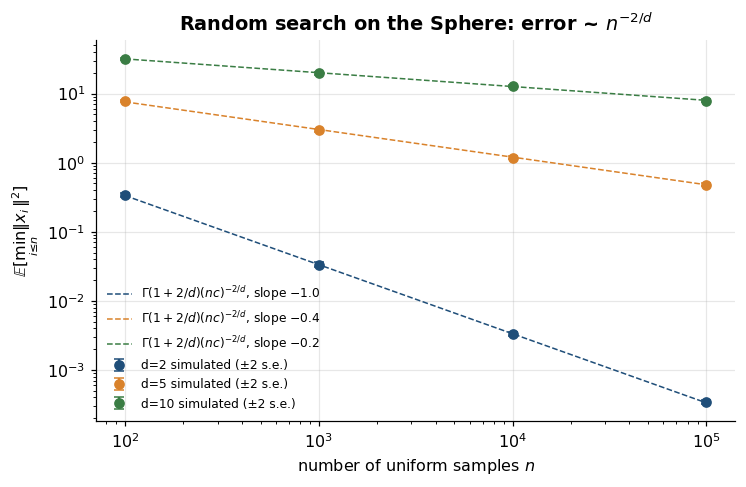

In [14]:
fig, ax = plt.subplots()
for d_, col in zip(reps, (PALETTE["blue"], PALETTE["orange"], PALETTE["green"])):
    ax.errorbar(ns, emp[d_], yerr=2 * emp_se[d_], fmt="o", color=col, capsize=3, label=f"d={d_} simulated (±2 s.e.)")
    nn = np.logspace(2, 5, 50)
    c = math.pi ** (d_ / 2) / gamma(d_ / 2 + 1) / (2 * a) ** d_
    ax.plot(nn, gamma(1 + 2 / d_) * (nn * c) ** (-2 / d_), "--", color=col, lw=1,
            label=rf"$\Gamma(1+2/d)(nc)^{{-2/d}}$, slope $-{2 / d_:.1f}$")
ax.set(xscale="log", yscale="log", xlabel="number of uniform samples $n$", ylabel=r"$\mathbb{E}[\min_{i\leq n} \Vert x_i\Vert^2]$",
       title="Random search on the Sphere: error ~ $n^{-2/d}$")
ax.legend(fontsize=8); savefig("w1_random_search_scaling.png"); plt.show()

The asymptotic constant is accurate as soon as the relevant ball fits in the box; for $d = 10$ and $n \le 1000$ the
best sample has a non-negligible chance of lying outside the inscribed ball, the tail bound is not small, and those
points were not checked. The curse of dimensionality is quantitative: after $10^5$ samples in $d = 10$, random
search's expected best Sphere value is still about 8, against about 0.5 in $d = 5$ and $3 \times 10^{-4}$ in $d = 2$
(printed and plotted above).

**AI/ML connection.** Random search is a strong baseline for hyperparameter optimisation (Bergstra & Bengio 2012)
because few hyperparameters usually matter — the *effective* dimension is small, and the $n^{-2/d_{\text{eff}}}$ law is
then benign. The harness above (budgets, seeds, median/IQR, ERT) is the same methodology used to compare HPO and NAS
methods fairly.

## Key takeaways
- The suite's recorded optima were verified; five functions (Sphere, Ellipsoid, Rastrigin, Schwefel, Levy) are
  additively separable — each Levy term depends on a single coordinate — which coordinate-wise search exploits and
  rotation removes. Rosenbrock, Ackley and Griewank are not separable.
- The course harness fixes the protocol: budgeted objective, seeded runs, best-so-far traces on a common grid,
  median/IQR, success rate and ERT; ERT matched its closed form $1/p$ for random search.
- At equal budgets in $d = 10$, a naive fixed-step hill climber beats random search on the unimodal functions but
  stalls at the step scale and can be worse than random search on multimodal ones; random restarts help on
  Rastrigin, Schwefel and Levy.
- Random search's expected error on the Sphere follows $\Gamma(1+2/d)(nc)^{-2/d}$, verified in $d = 2, 5, 10$.

## Exercises
1. ★ Prove that $\mathrm{ERT} = \mathbb{E}[\mathrm{RT}_{\text{succ}}] + \frac{1-p_s}{p_s}\mathbb{E}[\mathrm{RT}_{\text{fail}}]$ is the expected
   number of evaluations of the independently restarted algorithm until its first success.
2. ★ Show that for $d=2$, $\Delta_{12} \equiv 0$ implies $f(x_1, x_2) = g(x_1) + h(x_2)$, and that the Sphere remains
   separable under every rotation while the Ellipsoid does not.
3. ★★ Derive the next-order correction to $\mathbb{E}[M_n] \approx \Gamma(1+2/d)(nc)^{-2/d}$ from
   $(1-F)^n = e^{n\ln(1-F)}$, and check it against the `quad` values above.
4. ★★ Add Rechenberg's 1/5 success rule to the hill climber and rerun the harness. On which functions does step-size
   adaptation remove the stagnation, and what does it do on Rastrigin?
5. ★★ Implement empirical cumulative distribution functions of running times over a set of targets (COCO's
   "ECDF of runtimes") in the harness and plot them for the three baselines aggregated over all eight functions.
6. ★★★ Tune the step size $\sigma$ and patience $P$ of random-restart local search on the Sphere and Rastrigin with
   random search over $(\log\sigma, \log P)$ *using the harness itself as the objective*, and discuss the danger of
   reporting tuned-on-the-test-functions results (cf. Birattari's F-Race, 2002).